# It answered from last quarter's document

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/rag-staleness/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/rag-staleness/demo.ipynb)

A RAG index is a snapshot of documents that keep changing. The dashboard reports index freshness: the share of
documents whose indexed bytes still match the source. The user hits a different number: the share of *served
answers* whose chunk carries a fact that has since changed. This notebook declares a small corpus (three document
classes with their own edit rates and query shares), derives both numbers in closed form for three reindex
policies, checks the closed form against a raw simulation, and shows the two numbers ranking the policies in
opposite orders.

1. The model: a snapshot, a Poisson source, a uniform phase
2. Calibration - closed form vs raw simulation
3. Three policies, three numbers
4. Inside the cycle, and the archive that improves the metric
5. The retrieval score that cannot see staleness
6. Try your own

## The engine

Extracted from `staleness.py` at build time, character for character. A document class has `docs`, a mean
number of days between edits, the share of edits that change a fact a chunk carries, and the share of served
answers that retrieve from it. A policy is a reindex period per class. `stale(mu, T)` is the probability that a
document reindexed every `T` days, served at a uniform phase, carries a changed fact.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

SEED = 191


MC_REPS = 200_000


CLASSES: List[Dict] = [
    {"name": "hot", "docs": 10, "change_every": 14.0, "fact_share": 0.6, "query_share": 0.50,
     "what": "pricing, limits, policy"},
    {"name": "warm", "docs": 40, "change_every": 45.0, "fact_share": 0.5, "query_share": 0.35,
     "what": "how-to guides, release notes"},
    {"name": "cold", "docs": 150, "change_every": 365.0, "fact_share": 0.3, "query_share": 0.15,
     "what": "archive, legal, reference"},
]


POLICIES: Dict[str, Dict[str, float]] = {
    "v1 monthly full": {"hot": 30.0, "warm": 30.0, "cold": 30.0},
    "v2a weekly full": {"hot": 7.0, "warm": 7.0, "cold": 7.0},
    "v2b tiered 1/7/90": {"hot": 1.0, "warm": 7.0, "cold": 90.0},
}


FACTS: List[Tuple[str, str, str, str]] = [
    ("Pro plan", "includes", "5 seats", "8 seats"),
    ("Pro plan", "allows API calls per minute of", "600", "1200"),
    ("Pro plan", "offers refunds within", "30 days", "two weeks"),
    ("Pro plan", "stores logs for", "90 days", "30 days"),
    ("Basic plan", "includes", "2 seats", "3 seats"),
    ("Basic plan", "allows API calls per minute of", "60", "100"),
    ("Basic plan", "offers refunds within", "14 days", "7 days"),
    ("Basic plan", "stores logs for", "30 days", "7 days"),
    ("Enterprise plan", "includes", "50 seats", "unlimited seats"),
    ("Enterprise plan", "guarantees uptime of", "99.9 percent", "99.95 percent"),
    ("Enterprise plan", "responds to support tickets within", "4 hours", "1 hour"),
    ("Enterprise plan", "stores logs for", "365 days", "730 days"),
]


def stale(mu: float, period: float) -> float:
    """P(served chunk carries a changed fact) when the doc is reindexed every `period` days."""
    x = mu * period
    if x == 0:
        return 0.0
    return 1.0 + math.expm1(-x) / x  # expm1: 1 - (1 - e^-x)/x cancels catastrophically for small x


def stale_at(mu: float, days: float) -> float:
    """P(stale) `days` after the last reindex."""
    return -math.expm1(-mu * days)


def rates(c: Dict) -> Tuple[float, float]:
    """(lambda, mu): rate of any edit, rate of fact-bearing edits, per day."""
    lam = 1.0 / c["change_every"]
    return lam, lam * c["fact_share"]


def evaluate(policy: Dict[str, float], classes: Sequence[Dict] = CLASSES) -> Dict:
    """The three numbers plus cost, exactly."""
    n = sum(c["docs"] for c in classes)
    hash_stale = fact_stale = answer = cost = 0.0
    per: Dict[str, Dict[str, float]] = {}
    for c in classes:
        lam, mu = rates(c)
        T = policy[c["name"]]
        h, f = stale(lam, T), stale(mu, T)
        per[c["name"]] = {"period": T, "hash_stale": h, "fact_stale": f}
        hash_stale += c["docs"] * h
        fact_stale += c["docs"] * f
        answer += c["query_share"] * f
        cost += c["docs"] / T
    return {"hash_freshness": 1.0 - hash_stale / n, "fact_freshness": 1.0 - fact_stale / n,
            "answer_staleness": answer, "reindex_per_day": cost, "per_class": per, "docs": n}


def cycle(policy: Dict[str, float], days: int = 30, classes: Sequence[Dict] = CLASSES) -> List[Dict]:
    """Answer staleness on each day of a cycle, for classes whose period is >= `days` (others are at their
    own phase average)."""
    out = []
    for d in range(days + 1):
        a = 0.0
        for c in classes:
            _, mu = rates(c)
            T = policy[c["name"]]
            a += c["query_share"] * (stale_at(mu, min(d, T)) if T >= days else stale(mu, T))
        out.append({"day": d, "answer_staleness": a})
    return out


def with_archive(extra_docs: int, policy: Dict[str, float], period: float = 30.0,
                 classes: Sequence[Dict] = CLASSES) -> Tuple[List[Dict], Dict[str, float]]:
    """Add documents nobody asks about: cold change profile, zero query share, reindexed every `period`."""
    cls = list(classes) + [{"name": "archive", "docs": extra_docs, "change_every": 365.0, "fact_share": 0.3,
                            "query_share": 0.0, "what": "added, never retrieved"}]
    return cls, {**policy, "archive": period}


def audit_sample(policy: Dict[str, float], sample_from: str, classes: Sequence[Dict] = CLASSES) -> float:
    """Expected stale share in an audit sample: `docs` draws documents uniformly, `queries` draws them in
    proportion to query share. Each is an unbiased estimate of a different number."""
    n = sum(c["docs"] for c in classes)
    tot = 0.0
    for c in classes:
        _, mu = rates(c)
        w = c["docs"] / n if sample_from == "docs" else c["query_share"]
        tot += w * stale(mu, policy[c["name"]])
    return tot


def tokens(s: str) -> List[str]:
    return [t for t in s.lower().replace(",", " ").split() if t]


def jaccard(a: str, b: str) -> float:
    A, B = set(tokens(a)), set(tokens(b))
    return len(A & B) / len(A | B) if A | B else 0.0


def chunk(fact: Tuple[str, str, str, str], new: bool) -> str:
    e, attr, old, cur = fact
    return f"{e} {attr} {cur if new else old}."


def query(fact: Tuple[str, str, str, str]) -> str:
    e, attr, _, _ = fact
    return f"{e} {attr}"


def similarity_gap(facts: Sequence[Tuple[str, str, str, str]] = FACTS) -> Dict:
    """For each fact: similarity of the query to the stale chunk and to the fresh chunk. A gate that keeps
    every fresh chunk passes every stale chunk whose score is >= the lowest fresh score."""
    rows = []
    for f in facts:
        q = query(f)
        s_old, s_new = jaccard(q, chunk(f, False)), jaccard(q, chunk(f, True))
        rows.append({"query": q, "stale_sim": s_old, "fresh_sim": s_new, "gap": s_new - s_old})
    floor = min(r["fresh_sim"] for r in rows)
    passed = sum(r["stale_sim"] >= floor for r in rows)
    return {"rows": rows, "max_abs_gap": max(abs(r["gap"]) for r in rows),
            "stale_at_least_as_similar": sum(r["gap"] <= 0 for r in rows), "n": len(rows),
            "stale_passed_by_gate_keeping_all_fresh": passed / len(rows)}


def wilson(k: int, n: int, z: float = 2.5758) -> Tuple[float, float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return mid - half, mid + half


def simulate(policy: Dict[str, float], reps: int = MC_REPS, seed: int = SEED,
             classes: Sequence[Dict] = CLASSES) -> Dict:
    """Raw simulation of the model: a uniform phase, Poisson edits in it, each fact-bearing with prob
    fact_share; a served answer draws its class by query share. Returns counts for a Wilson check."""
    rng = np.random.default_rng(seed)
    out: Dict[str, Tuple[int, int]] = {}
    for c in classes:
        lam, _ = rates(c)
        T = policy[c["name"]]
        u = rng.uniform(0, T, reps)
        edits = rng.poisson(lam * u)
        fact_edits = rng.binomial(edits, c["fact_share"])
        out[f"{c['name']} hash_stale"] = (int((edits > 0).sum()), reps)
        out[f"{c['name']} fact_stale"] = (int((fact_edits > 0).sum()), reps)
    shares = np.array([c["query_share"] for c in classes])
    pick = rng.choice(len(classes), size=reps, p=shares / shares.sum())
    k = 0
    for i, c in enumerate(classes):
        lam, _ = rates(c)
        m = int((pick == i).sum())
        u = rng.uniform(0, policy[c["name"]], m)
        k += int((rng.binomial(rng.poisson(lam * u), c["fact_share"]) > 0).sum())
    out["answer_staleness"] = (k, reps)
    return out


def calibrate(reps: int = MC_REPS, seed: int = SEED, policies: Optional[Dict[str, Dict[str, float]]] = None,
              classes: Sequence[Dict] = CLASSES) -> List[Dict]:
    pols = policies or {k: POLICIES[k] for k in ("v1 monthly full", "v2b tiered 1/7/90")}
    rows = []
    for s, (pname, pol) in enumerate(pols.items()):
        ex = evaluate(pol, classes)
        sim = simulate(pol, reps, seed + s, classes)
        for key, (k, n) in sim.items():
            if key == "answer_staleness":
                exact = ex["answer_staleness"]
            else:
                cname, what = key.split(" ")
                exact = ex["per_class"][cname][what]
            lo, hi = wilson(k, n)
            rows.append({"policy": pname, "quantity": key, "exact": exact, "mc": k / n,
                         "inside_99": bool(lo <= exact <= hi)})
    return rows


def parse_classes(text: str) -> List[Dict]:
    """`name, docs, change_every_days, fact_share, query_share` per line. Query shares are normalised."""
    out = []
    for raw in text.strip().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        parts = [p.strip() for p in line.split(",")]
        if len(parts) != 5:
            raise ValueError(f"need 5 comma-separated fields, got {len(parts)}: {line!r}")
        name, docs, ce, fs, qs = parts
        try:
            c = {"name": name, "docs": int(docs), "change_every": float(ce), "fact_share": float(fs),
                 "query_share": float(qs), "what": ""}
        except ValueError:
            raise ValueError(f"numbers did not parse on {line!r}")
        if c["docs"] <= 0 or c["change_every"] <= 0 or not 0 <= c["fact_share"] <= 1 or c["query_share"] < 0:
            raise ValueError(f"out of range on {line!r}: docs > 0, change_every > 0, 0 <= fact_share <= 1, "
                             "query_share >= 0")
        out.append(c)
    if not out:
        raise ValueError("need at least one document class")
    if len({c["name"] for c in out}) != len(out):
        raise ValueError("class names must be unique")
    tot = sum(c["query_share"] for c in out)
    if tot <= 0:
        raise ValueError("query shares sum to zero - nobody asks anything")
    for c in out:
        c["query_share"] /= tot
    return out


def parse_policy(text: str, classes: Sequence[Dict]) -> Dict[str, float]:
    """A single number (every class) or `name=days` pairs, comma separated, one per class."""
    text = text.strip()
    names = [c["name"] for c in classes]
    try:
        T = float(text)
        if T <= 0:
            raise ValueError
        return {n: T for n in names}
    except ValueError:
        pass
    pol: Dict[str, float] = {}
    for part in text.split(","):
        if "=" not in part:
            raise ValueError(f"expected name=days, got {part.strip()!r}")
        n, d = (p.strip() for p in part.split("=", 1))
        try:
            pol[n] = float(d)
        except ValueError:
            raise ValueError(f"days did not parse in {part.strip()!r}")
        if pol[n] <= 0:
            raise ValueError(f"period must be > 0 in {part.strip()!r}")
    missing = [n for n in names if n not in pol]
    if missing:
        raise ValueError(f"policy gives no period for {missing}")
    return pol

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every policy number here is closed-form and matches `evidence.txt` to the
digit. Only the calibration's raw simulation runs at 20,000 replicates instead of the study's 200,000.

## 1. The model

In [2]:
for c in CLASSES:
    lam, mu = rates(c)
    print(f"{c['name']:<5} {c['docs']:>4} docs  edited every {c['change_every']:>4.0f} d  fact-bearing {c['fact_share']:.0%}  "
          f"query share {c['query_share']:.0%}   ({c['what']})")
print()
print("stale(mu, T) = 1 - (1 - exp(-mu T)) / (mu T)")
for T in (1, 7, 30, 90):
    print(f"  hot doc reindexed every {T:>2} days: served stale {stale(rates(CLASSES[0])[1], T):.1%} of the time")

hot     10 docs  edited every   14 d  fact-bearing 60%  query share 50%   (pricing, limits, policy)
warm    40 docs  edited every   45 d  fact-bearing 50%  query share 35%   (how-to guides, release notes)
cold   150 docs  edited every  365 d  fact-bearing 30%  query share 15%   (archive, legal, reference)

stale(mu, T) = 1 - (1 - exp(-mu T)) / (mu T)
  hot doc reindexed every  1 days: served stale 2.1% of the time
  hot doc reindexed every  7 days: served stale 13.6% of the time
  hot doc reindexed every 30 days: served stale 43.7% of the time
  hot doc reindexed every 90 days: served stale 74.6% of the time


The hot class is 5% of the documents and half of the answers. Monthly reindexing leaves a hot document
serving a changed fact 44% of the time.

## 2. Calibration

In [3]:
cal = calibrate(20000)
print(f"inside their 99% interval: {sum(r['inside_99'] for r in cal)} of {len(cal)}")

inside their 99% interval: 14 of 14


## 3. Three policies, three numbers

In [4]:
ev = {k: evaluate(p) for k, p in POLICIES.items()}
print(f"{'policy':<18} {'hash fresh':>10} {'fact fresh':>10} {'answers stale':>13} {'reindex/day':>11}")
for k, e in ev.items():
    print(f"{k:<18} {e['hash_freshness']:>10.1%} {e['fact_freshness']:>10.1%} {e['answer_staleness']:>13.1%} "
          f"{e['reindex_per_day']:>11.1f}")
v1, wk, ti = ev["v1 monthly full"], ev["v2a weekly full"], ev["v2b tiered 1/7/90"]
deltas = {"weekly: hash freshness": wk["hash_freshness"] - v1["hash_freshness"],
          "weekly: answer staleness": wk["answer_staleness"] - v1["answer_staleness"],
          "tiered: hash freshness": ti["hash_freshness"] - v1["hash_freshness"],
          "tiered: answer staleness": ti["answer_staleness"] - v1["answer_staleness"]}
print()
for k, d in deltas.items():
    print(f"{k:<28} {d * 100:+6.1f} pts")
print(f"weekly full serves {wk['answer_staleness'] / ti['answer_staleness']:.1f}x the stale answers of tiered at "
      f"{wk['reindex_per_day'] / ti['reindex_per_day']:.1f}x the reindex cost")

policy             hash fresh fact fresh answers stale reindex/day
v1 monthly full         88.7%      93.9%         27.3%         6.7
v2a weekly full         96.7%      98.3%          8.2%        28.6
v2b tiered 1/7/90       89.8%      96.4%          2.9%        17.4

weekly: hash freshness         +8.1 pts
weekly: answer staleness      -19.1 pts
tiered: hash freshness         +1.2 pts
tiered: answer staleness      -24.4 pts
weekly full serves 2.8x the stale answers of tiered at 1.6x the reindex cost


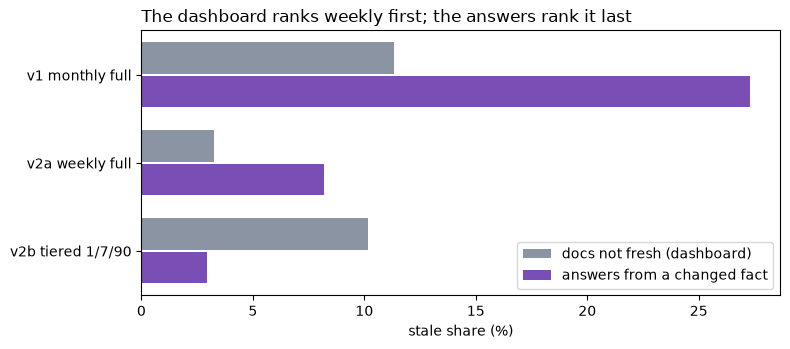

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
names = list(ev)
ys = np.arange(len(names))[::-1]
ax.barh(ys + 0.19, [(1 - ev[n]["hash_freshness"]) * 100 for n in names], 0.36, color="#8a94a3", label="docs not fresh (dashboard)")
ax.barh(ys - 0.19, [ev[n]["answer_staleness"] * 100 for n in names], 0.36, color="#7a4fb5", label="answers from a changed fact")
ax.set_yticks(ys); ax.set_yticklabels(names); ax.set_xlabel("stale share (%)"); ax.legend(loc="lower right")
ax.set_title("The dashboard ranks weekly first; the answers rank it last", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

Weekly full reindexing moves the dashboard 8 points and the answers 19. The tiered schedule moves the
dashboard 1 point and the answers 24, at 60% of the cost. Sorted by index freshness, weekly wins; sorted by
what the user receives, tiered wins by 2.8x.

## 4. Inside the cycle, and the archive

In [6]:
cyc = cycle(POLICIES["v1 monthly full"])
for d in (1, 7, 14, 29):
    print(f"day {d:>2} of the monthly cycle: {cyc[d]['answer_staleness']:.1%} of answers stale")
print(f"phase average, what a monthly metric reports: {v1['answer_staleness']:.1%}")
print()
for extra in (0, 300, 1000):
    cls, pol = with_archive(extra, POLICIES["v1 monthly full"])
    e = evaluate(pol, cls)
    print(f"+{extra:>4} archive docs nobody asks about: index freshness {e['hash_freshness']:.1%}, answers stale {e['answer_staleness']:.1%}")
print()
print(f"audit by sampling documents uniformly estimates {audit_sample(POLICIES['v1 monthly full'], 'docs'):.1%}; "
      f"by sampling the query log, {audit_sample(POLICIES['v1 monthly full'], 'queries'):.1%}")

day  1 of the monthly cycle: 2.5% of answers stale
day  7 of the monthly cycle: 15.7% of answers stale
day 14 of the monthly cycle: 27.8% of answers stale
day 29 of the monthly cycle: 45.6% of answers stale
phase average, what a monthly metric reports: 27.3%

+   0 archive docs nobody asks about: index freshness 88.7%, answers stale 27.3%
+ 300 archive docs nobody asks about: index freshness 93.1%, answers stale 27.3%
+1000 archive docs nobody asks about: index freshness 94.8%, answers stale 27.3%

audit by sampling documents uniformly estimates 6.1%; by sampling the query log, 27.3%


The user on day 29 gets 46% stale answers against a reported 27%. Adding a thousand archive documents raises
index freshness six points and changes no answer. A uniform document sample is an unbiased estimate of the
dashboard's number; only a sample drawn from the query log estimates the user's.

## 5. The retrieval score

In [7]:
sg = similarity_gap()
for r in sg["rows"][:4]:
    print(f"{r['query']:<44} stale {r['stale_sim']:.3f}  fresh {r['fresh_sim']:.3f}  gap {r['gap']:+.3f}")
print(f"... {sg['n']} facts, max |gap| {sg['max_abs_gap']:.3f}; a gate that keeps every fresh chunk passes "
      f"{sg['stale_passed_by_gate_keeping_all_fresh']:.0%} of stale ones")

Pro plan includes                            stale 0.600  fresh 0.600  gap +0.000
Pro plan allows API calls per minute of      stale 0.889  fresh 0.889  gap +0.000
Pro plan offers refunds within               stale 0.714  fresh 0.714  gap +0.000
Pro plan stores logs for                     stale 0.714  fresh 0.714  gap +0.000
... 12 facts, max |gap| 0.000; a gate that keeps every fresh chunk passes 100% of stale ones


The query names the attribute and never the value, so swapping the value changes nothing the score can see.
Confidence is not a staleness signal, by construction.

## Summary

| claim | what the numbers say |
|---|---|
| "the index is 89% fresh" | and 27% of answers carry a changed fact: the queries land on the 5% of docs that move |
| "weekly reindexing fixed it" | index +8 pts, answers -19; the tiered schedule is +1 and -24 at 60% of the cost |
| "the monthly number is 27%" | it is 2.5% on day 1 and 46% on day 29 |
| "freshness went up this quarter" | 1,000 archive docs did that; no answer changed |
| "the retriever was confident" | identical similarity for the stale and the fresh chunk, 12 of 12 facts |

## 6. Try your own

In [8]:
# cls = parse_classes("pricing, 5, 10, 0.7, 6\nguides, 60, 60, 0.5, 3\nlegal, 200, 400, 0.2, 1")
# for name, text in (("daily full", "1"), ("tiered", "pricing=1, guides=14, legal=120")):
#     e = evaluate(parse_policy(text, cls), cls)
#     print(name, f"index fresh {e['hash_freshness']:.1%}  answers stale {e['answer_staleness']:.1%}  "
#           f"reindex/day {e['reindex_per_day']:.1f}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/rag-staleness)

Streamlit version, where you describe your own corpus classes and reindex policies:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`data-freshness-monitor`](../../data-infra-toolkit/data-freshness-monitor) asks whether a table
is late; this build asks whether the answers served from an index are out of date, which is a different
weighting of a different quantity. [`citation-verifier`](../citation-verifier) is the previous day's audit of
a metric that moved against the truth.